# Compare performance of LFP-input vs jitter-only models

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
from bootstrap_method import *


2025-10-30 00:15:14.897915: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-30 00:15:14.906585: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-30 00:15:14.915781: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-30 00:15:14.918504: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-30 00:15:14.926403: I tensorflow/core/platform/cpu_feature_guar

### delay 400

In [2]:
delay = 400
condn_phrase = 'delay400.'
condn_num = ''

In [3]:
# find folder names within model directory
all_lfp_models_dir = '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/'
lfp_model_dirs = ld.get_immediate_subdirs(all_lfp_models_dir)
theta4_dirs = [m for m in lfp_model_dirs if '4.0' in m] # 4Hz models only

# get jitter-only models with same noise params as LFP models
all_jitter_models_dir = '/home/nuttidalab/Documents/renee/jitter_models/models/xor/P_rec_0.2_Taus_4.0_25.0/'
jitter_model_dirs = ld.get_immediate_subdirs(all_jitter_models_dir)
jitter_dirs = [m for m in jitter_model_dirs if 'Jitter_10_2' in m] # only models with same jitter amts as LFP models

In [4]:
print(theta4_dirs)
print(len(theta4_dirs))
print(jitter_dirs)
print(len(jitter_dirs))

['Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135100', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_10_10_121830', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_10_10_120946', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_122821', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_141248', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_10_10_121810', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121726', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121802', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_10_10_121301', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140736', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134559', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134527', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121653', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121450', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_122352', 'Task_x

In [5]:
# remove the 4Hz models that did not perform well on the delay=50 task

importlib.reload(ld)

spiking_perf = []
for model_name in theta4_dirs:
    mat_data = ld.get_model(model_name, all_models_dir=all_lfp_models_dir)
    perf = np.max(mat_data['all_perfs'])
    spiking_perf.append(perf)
    
# remove low-perf models from theta4_dirs
high_perf_theta4_dirs = []
for i, perf in enumerate(spiking_perf):
    if perf >= 0.95:
        high_perf_theta4_dirs.append(theta4_dirs[i])
        
theta4_dirs = high_perf_theta4_dirs
print(f'New number of 4Hz models: {len(theta4_dirs)}')

New number of 4Hz models: 24


In [6]:
# remove the jitter models that did not perform well on the delay=10 task

importlib.reload(ld)

spiking_perf = []
for model_name in jitter_dirs:
    mat_data = ld.get_model(model_name, all_models_dir=all_jitter_models_dir)
    perf = np.max(mat_data['all_perfs'])
    spiking_perf.append(perf)

# remove low-perf models from jitter_dirs
high_perf_jitter_dirs = []
for i, perf in enumerate(spiking_perf):
    if perf >= 0.95:
        high_perf_jitter_dirs.append(jitter_dirs[i])

jitter_dirs = high_perf_jitter_dirs
print(f'New number of Jitter models: {len(jitter_dirs)}')

New number of Jitter models: 20


In [7]:
# get all of the 4Hz and 8Hz models and their performances
importlib.reload(ld)
theta4_models, theta4_perfs = ld.get_models_by_perf(low_cutoff=-np.inf, high_cutoff=np.inf, 
                                              condn_phrase=condn_phrase, condn_num=condn_num,
                                              model_list = theta4_dirs,
                                              all_models_dir = all_lfp_models_dir)
jitter_models, jitter_perfs = ld.get_models_by_perf(low_cutoff=-np.inf, high_cutoff=np.inf, 
                                              condn_phrase=condn_phrase, condn_num=condn_num,
                                                model_list = jitter_dirs,
                                              all_models_dir = all_jitter_models_dir)

Found 24 models with performance between -inf and inf
Found 20 models with performance between -inf and inf


Mann-Whitney U test p-value: 0.0008877744680334398


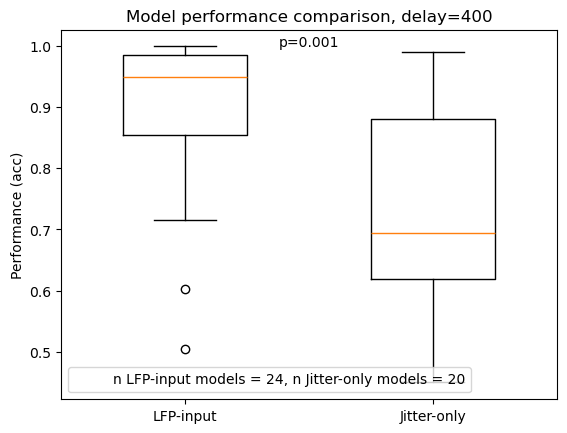

In [8]:
# boxplots comparing performance of LFP-input vs jitter-only models
data = [theta4_perfs, jitter_perfs]
fig, ax = plt.subplots()
ax.boxplot(data, widths=0.5)
ax.set_xticklabels(['LFP-input', 'Jitter-only'])
ax.set_ylabel('Performance (acc)')
ax.set_title('Model performance comparison, delay={}'.format(delay))

from scipy.stats import mannwhitneyu
stat, p = mannwhitneyuz(theta4_perfs, jitter_perfs)
print('Mann-Whitney U test p-value: {}'.format(p))
plt.text(1.5, max(max(theta4_perfs), max(jitter_perfs)), 'p={:.3f}'.format(p), ha='center')

plt.legend([patches.Patch(color='white')], ['n LFP-input models = {}, n Jitter-only models = {}'.format(len(theta4_perfs), len(jitter_perfs))])

plt.show()

[0, 22, 7, 16, 11, 9, 2, 15, 14, 8, 13, 3, 18, 21, 6, 19, 23, 4, 20, 17]
Mann-Whitney U test: stat=76.500, p=0.001
20 20


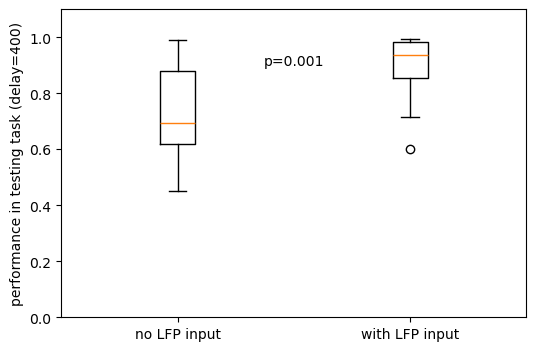

In [ ]:
## for abstract — choose 20 for each

# i_model = np.random.choice(len(theta4_perfs), size=20, replace=False)
i_model = [ 0, 22,  7, 16, 11,  9,  2, 15, 14,  8, 13,  3, 18, 21,  6, 19, 23,  4, 20, 17]
print(i_model)

# compare performance in delay=400 task

# choose 20 models for each
xlfp_perfs_test = jitter_perfs
lfp_perfs_test = theta4_perfs[i_model]

plt.figure(figsize=(6,4))
plt.boxplot([xlfp_perfs_test, lfp_perfs_test], positions=[1, 2])
plt.xticks([1, 2], ['no LFP input', 'with LFP input'])
plt.ylabel('performance in testing task (delay=400)')
plt.ylim([0, 1.1])
# plt.title('jitter models trained with/without LFP input (delay=400, testing task)')

from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(xlfp_perfs_test, lfp_perfs_test)
print('Mann-Whitney U test: stat=%.3f, p=%.3f' % (stat, p))
plt.text(1.5, 0.9, 'p=%.3f' % p, ha='center')

print(len(xlfp_perfs_test), len(lfp_perfs_test))

# save as eps
# plt.savefig('spiking_model_20_perf_comparison_delay400.eps', format='eps', dpi=1000)

plt.show()

## plot outputs

In [8]:
lfp_model = 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134255'

[i for i, m in enumerate(theta4_models) if m == lfp_model]

[13]

In [9]:
def load_bhv_outputs_jitter(model_name, condn_phrase, all_models_dir):
    
    model_dir = os.path.join(all_models_dir, model_name)
    bhvdata_path = ld.find_files_keywords(model_dir, ['bhvdata', condn_phrase])[0]
    if bhvdata_path == []:
        print(f'No behavioral data found for {model_name} with condition {condn_phrase}')
        return None, None

    # Load the data
    bhv_mat = scipy.io.loadmat(bhvdata_path)
    trial_labels = bhv_mat['all_trial_labels']
    trial_perfs = bhv_mat['all_trial_perfs'].flatten()
    trial_outs = bhv_mat['all_trial_outputs']
    
    return trial_labels, trial_perfs, trial_outs

def load_bhv_outputs_lfp(model_name, condn_phrase, all_models_dir):
    
    model_dir = os.path.join(all_models_dir, model_name)
    bhvdata_path = ld.find_files_keywords(model_dir, ['temp_outputs'])[0]
    if bhvdata_path == []:
        print(f'No behavioral data found for {model_name} with condition {condn_phrase}')
        return None, None

    # Load the data
    bhv_mat = scipy.io.loadmat(bhvdata_path)
    trial_labels = bhv_mat['all_trial_labels']
    trial_perfs = bhv_mat['all_trial_perfs'].flatten()
    trial_outs = bhv_mat['all_trial_outputs']
    
    return trial_labels, trial_perfs, trial_outs

In [24]:
jitter_model = jitter_models[1]
lfp_model = theta4_models[13]

# load output file
xlfp_labels, xlfp_perfs, xlfp_outs = load_bhv_outputs_jitter(jitter_model, condn_phrase, all_jitter_models_dir)
lfp_labels, lfp_perfs, lfp_outs = load_bhv_outputs_lfp(lfp_model, condn_phrase, all_lfp_models_dir)

In [11]:
times_fs, _, _ = ld.get_times_dict(100, condn_phrase, '', model_name=lfp_model, all_models_dir=all_lfp_models_dir)
times_fs

{'stim1_on': 25.5,
 'stim1_off': 50.5,
 'stim2_on': 250.5,
 'stim2_off': 275.5,
 'T': 325.5,
 'delay': 200.0,
 'stim_dur': 25.0,
 'fs': 100}

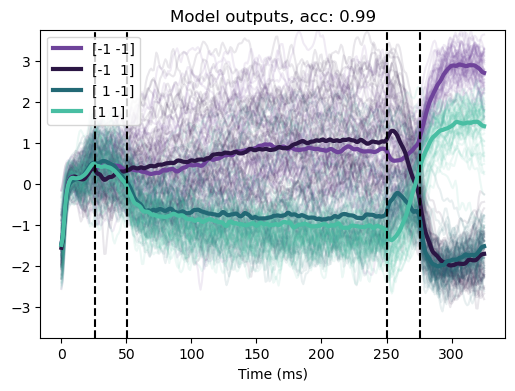

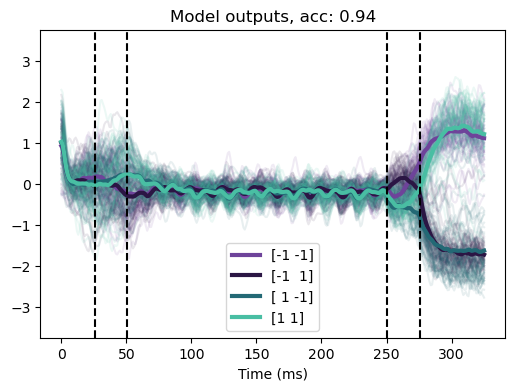

In [29]:
# plot outputs

for trial_labels, trial_perfs, trial_outs in [(xlfp_labels, xlfp_perfs, xlfp_outs), (lfp_labels, lfp_perfs, lfp_outs)]:
    plt.figure(figsize=(6,4))
    unique_labels = np.unique(trial_labels, axis=0)
    stims, colors = ld.get_trialtype_colors()
    
    # plot indv trials as transparent lines
    for i in range(unique_labels.shape[0]):
        trial_type = unique_labels[i]
        trial_indices = np.where((trial_labels == trial_type).all(axis=1))[0]
        for ti in trial_indices:
            plt.plot(trial_outs[ti, :], color=colors[i], alpha=0.1)
    
    # plot mean on top
    for i in range(unique_labels.shape[0]):
        trial_type = unique_labels[i]
        trial_indices = np.where((trial_labels == trial_type).all(axis=1))[0]
        mean_output = np.mean(trial_outs[trial_indices, :], axis=0)
        plt.plot(mean_output, color=colors[i], linewidth=3, label=f'{unique_labels[i]}')
    plt.xlabel('Time (ms)')
    plt.ylim([-3.75, 3.75])
    plt.legend()
    
    plt.axvline(x=times_fs['stim1_on'], color='k', linestyle='--')
    plt.axvline(x=times_fs['stim1_off'], color='k', linestyle='--')
    plt.axvline(x=times_fs['stim2_on'], color='k', linestyle='--')
    plt.axvline(x=times_fs['stim2_off'], color='k', linestyle='--')
    
    plt.title(f'Model outputs, acc: {np.mean(trial_perfs):.2f}')
    
    # save as eps
    # plt.savefig('SfN_spikingmodel_outputs_{}.svg'.format('jitter' if trial_outs is xlfp_outs else 'lfp'), format='svg', dpi=1000)
    
    plt.show()

In [16]:
jitter_perfs

array([0.62 , 0.99 , 0.745, 0.955, 0.77 , 0.63 , 0.62 , 0.69 , 0.885,
       0.9  , 0.88 , 0.7  , 0.45 , 0.51 , 0.675, 0.535, 0.595, 0.975,
       0.615, 0.7  ])

In [21]:
jitter_model = jitter_models[3]
lfp_model = theta4_models[13]

# load output file
xlfp_labels, xlfp_perfs, xlfp_outs = load_bhv_outputs_jitter(jitter_model, condn_phrase, all_jitter_models_dir)
lfp_labels, lfp_perfs, lfp_outs = load_bhv_outputs_lfp(lfp_model, condn_phrase, all_lfp_models_dir)

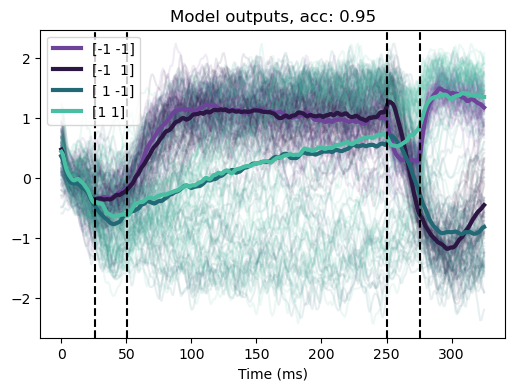

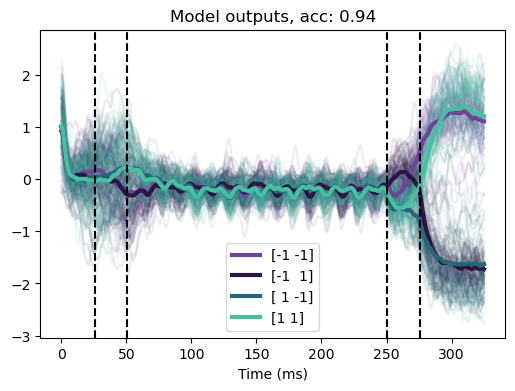

In [22]:
# plot outputs

for trial_labels, trial_perfs, trial_outs in [(xlfp_labels, xlfp_perfs, xlfp_outs), (lfp_labels, lfp_perfs, lfp_outs)]:
    plt.figure(figsize=(6,4))
    unique_labels = np.unique(trial_labels, axis=0)
    stims, colors = ld.get_trialtype_colors()
    
    # plot indv trials as transparent lines
    for i in range(unique_labels.shape[0]):
        trial_type = unique_labels[i]
        trial_indices = np.where((trial_labels == trial_type).all(axis=1))[0]
        for ti in trial_indices:
            plt.plot(trial_outs[ti, :], color=colors[i], alpha=0.1)
    
    # plot mean on top
    for i in range(unique_labels.shape[0]):
        trial_type = unique_labels[i]
        trial_indices = np.where((trial_labels == trial_type).all(axis=1))[0]
        mean_output = np.mean(trial_outs[trial_indices, :], axis=0)
        plt.plot(mean_output, color=colors[i], linewidth=3, label=f'{unique_labels[i]}')
    plt.xlabel('Time (ms)')
    plt.legend()
    
    plt.axvline(x=times_fs['stim1_on'], color='k', linestyle='--')
    plt.axvline(x=times_fs['stim1_off'], color='k', linestyle='--')
    plt.axvline(x=times_fs['stim2_on'], color='k', linestyle='--')
    plt.axvline(x=times_fs['stim2_off'], color='k', linestyle='--')
    
    plt.title(f'Model outputs, acc: {np.mean(trial_perfs):.2f}')
    plt.show()

### plot rate model outputs

In [7]:
# delay400
settings = {
        'T': 650, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 400, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4], # theta
        'power_target_period': 'delay',
        'fs': 200,
        'task': 'xor', # task name
        }

In [11]:
jitter_model = jitter_dirs[1]
lfp_model = theta4_dirs[13]

In [12]:
import pickle as pk

# compare performance in delay=400 task

xlfp_outputdir = all_jitter_models_dir + '/' + jitter_model + '/'
lfp_outputdir = all_lfp_models_dir + '/' + lfp_model + '/'

with open(os.path.join(xlfp_outputdir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'rb') as f:
    xlfp_bhv_dict = pk.load(f)
    
with open(os.path.join(lfp_outputdir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'rb') as f:
    lfp_bhv_dict = pk.load(f)
    
xlfp_perf = np.mean(xlfp_bhv_dict["perf"])
lfp_perf = np.mean(lfp_bhv_dict["perf"])

print(f'Jitter-only model performance (delay={settings["delay"]}): {xlfp_perf:.3f}')
print(f'LFP model performance (delay={settings["delay"]}): {lfp_perf:.3f}')

print(xlfp_bhv_dict.keys())
print(lfp_bhv_dict.keys())

FileNotFoundError: [Errno 2] No such file or directory: '/home/nuttidalab/Documents/renee/jitter_models/models/xor/P_rec_0.2_Taus_4.0_25.0//Task_xor_N_200_Jitter_10_2_2025_10_24_111225/bhv_dict_delay400.pkl'